# Chapter 4
## 분류

#### 03. 앙상블 학습 

##### 앙상블 학습 개요
앙상블 학습 (Ensenble Learning) : 
- 여러 개의 분류기를 생서하고 그 예측을 결합함으로써 보다 정확한 최종 예측을 도출하는 기법 
- 랜덤 포레스트, 그래디언트 부스팅 
- LightGBM,XGboost 

앙상블의 학습 유형 
- 보팅 (Voting)
    - 여러 개의 분류기가 투표를 통해 최종 예측 결과를 결정
    - 하드 보팅 (Hard Voting)
        - Classification의 다수결 원칙과 비슷하다
        - 예측한 결괏값들 중 다수의 분류기가 결정한 예측값을 최종 보팅 결괏값으로 선정한다
    - 소프트 보팅 (Soft Voting)
        - 분류기들의 레이블 값 결정 확률을 모두 더하고 이를 평균해서 이들 중 확률이 가장 높은 레이블 값을 최종 보팅 결괏값으로 선정 
        - 일반적으로 가장 많이 사용되는 보팅 방식
- 배깅 (Bagging)
    - 여러 개의 분류기가 투표를 통해 최종 예측 결과를 결정
    - 분류기가 모두 같은 유형을 알고리즘 기반, 데이터 샘플링이 다르다
    - 대표적 방식 : 랜덤 포레스트
    - 중첩 허용
- 부스팅 (Boosting)
    - 여러 개의 분류기가 순차적으로 학습을 수행하되, 앞에서 학습한 분류기가 예측이 틀린 데이터에 대해서는 올바르게 예측할 수 있도록 다음 분류기에서 가중치를 부여
    - 학습과 예측을 진행 
    - 예측 성능이 뛰어남
    - 예 : 그래디언트 부스트, XGBoost, LightGBM

보팅 분류기 (Voting Classifier)
- 사이킷런에서 제공
- VotingClassifier 클래스를 이용해 보팅 분류기를 생성할 수 있다
    - 주요 생성 인자 
        - estimators : 리스트 값으로 보팅에 사용될 여러 개의 classifier 객체들을 튜플 형식으로 입력받는다
        - Classifier : voting : 'hard'시 하드 보팅(기본), 'soft'시 소프트 보팅을 적용하라는 의미



In [1]:
# 필요한 모듈과 데이터를 로딩한 후 위스콘신 데이터 세트 살펴보기
import pandas as pd

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()

data_df = pd.DataFrame(cancer.data, columns = cancer.feature_names)
data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


로지스틱 회귀와 KNN을 기반으로 소프트 보팅 방식으로 새롭게 보팅 분류기 만들기

In [2]:
# 개별 모델은 로지스틱 회귀와 KNN임.
Ir_clf = LogisticRegression(solver='liblinear')
knn_clf = KNeighborsClassifier(n_neighbors=8)

# 개별 모델을 소프트 보팅 기반의 앙상블 모델로 구현한 분류기
vo_clf = VotingClassifier(estimators=[('LR', Ir_clf), ('KNN', knn_clf)], voting='soft')
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=156)

# VotingClassifier 학습/예측/평가.
vo_clf.fit(X_train, y_train)
pred = vo_clf.predict(X_test)
print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

# 개별 모델의 학습/예측/평가.
classifiers = [Ir_clf, knn_clf]
for classifier in classifiers:
  classifier.fit(X_train, y_train)
  pred = classifier.predict(X_test)
  class_name = classifier.__class__.__name__
  print('{0} 정확도: {1:.4f}'.format(class_name, accuracy_score(y_test, pred)))

Voting 분류기 정확도: 0.9561
LogisticRegression 정확도: 0.9474
KNeighborsClassifier 정확도: 0.9386


#### 04. 랜덤 포레스트

##### 랜덤 포레스트의 개요 및 실습 
배깅은 앞에서 소개한 보팅과는 다르게, 같은 알고리즘으로 여러 개의 분류기를 만들어서 보팅으로 최종 결정하는 알고리즘이다. 이의 대표적인 알고리즘은 랜덤 포레스트다

랜덤 포레스트 
- 기반 알고리즘 : 결점 트리 (직관적인 장점을 그대로 가지고 있다)
- 여러 개의 결정 트리 분류기가 전체 데이터에서 배깅 방식으로 각자의 데이터를 샘플링해 개별적으로 학습을 수행한 뒤, 최종적으로 모든 분류기가 보팅을 통해 예측 결정을 하게 된다
- 부트스트래핑 (bootstrapping) 분할 방식 :  개별 트리가 학습하는 데이터 세트는 전체 데이터에서 일부가 중첩되게 샘플링된 데이터 세트다 
- 랜덤 포레스트의 서브세트 데이터는 이러한 부트스트래핑으로 데이터가 임의로 만들어진다. 개별 데이터가 중첩되어 만들어짐  (n_estimators = 3)
- RandomForestClassifier 클래스로 분류 지원 

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(
        data=old_feature_name_df.groupby('column_name').cumcount(),
        columns=['dup_cnt']
    )
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(
        lambda x: x['column_name'] + '_' + str(x['dup_cnt']) if x['dup_cnt'] > 0 else x['column_name'],
        axis=1
    )
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

def get_human_dataset():
    feature_name_df = pd.read_csv('/Users/seomichelle/26-1 ESAA:Python/datasets/features.txt', sep='\s+',
                                  header=None, names=['column_index', 'column_name'])
    new_feature_name_df = get_new_feature_name_df(feature_name_df)
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    X_train = pd.read_csv('/Users/seomichelle/26-1 ESAA:Python/datasets/human activity/X_train.txt', sep='\s+', names=feature_name)
    X_test = pd.read_csv('/Users/seomichelle/26-1 ESAA:Python/datasets/human activity/X_test.txt', sep='\s+', names=feature_name)
    y_train = pd.read_csv('/Users/seomichelle/26-1 ESAA:Python/datasets/human activity/y_train.txt', sep='\s+', header=None, names=['action'])
    y_test = pd.read_csv('/Users/seomichelle/26-1 ESAA:Python/datasets/human activity/y_test.txt', sep='\s+', header=None, names=['action'])
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_human_dataset()

# 랜덤 포레스트 학습 및 별도의 테스트 세트로 예측 성능 평가
rf_clf = RandomForestClassifier(random_state=0, max_depth=8)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy))

랜덤 포레스트 정확도: 0.9192


##### 랜덤 포레스트 하이퍼 파라미터 튜닝 
- n_estimators: 결정 트리 개수 결정
- max_features: 결정 트리에서 사용된 max_features 파라미터와 같음
- max_depth, min_samples_leat, min_samples_split 등 결정 트리에서 사용한 과적합 개선 똑같이 적용 가능

GridSearchCV를 이용해 랜덤 포레스트의 하이퍼 파라미터 튜닝

In [21]:

from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [8, 16, 24],
    'min_samples_leaf': [1, 6, 12],
    'min_samples_split': [2, 8, 16]
}

# RandomForestClassifier 객체 생성 후 GridSearchCV 수행
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
grid_cv = GridSearchCV(rf_clf, param_grid=params, cv=2, n_jobs=-1)
grid_cv.fit(X_train, y_train)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print('최고 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:
 {'max_depth': 24, 'min_samples_leaf': 6, 'min_samples_split': 2}
최고 예측 정확도: 0.9162


별도의 테스트 데이터 세트에서 예측 성능 측정

In [22]:
rf_clf1 = RandomForestClassifier(n_estimators=100, min_samples_leaf=6, max_depth=16,
                                 min_samples_split=2, random_state=0)
rf_clf1.fit(X_train, y_train)
pred = rf_clf1.predict(X_test)
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9264


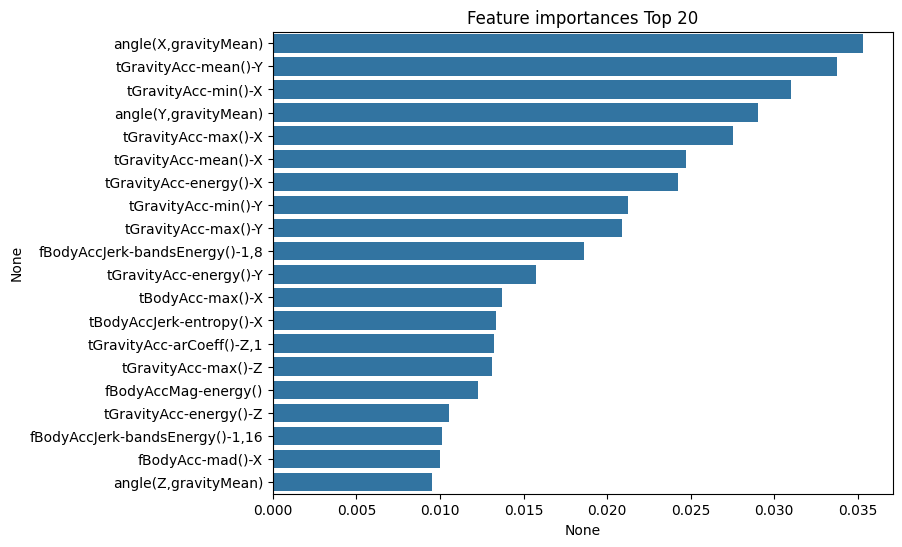

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ftr_importances_values = rf_clf1.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()

#### 05. GBM (Gradient Boosting Machine)

##### GBM의 개요 및 실습 
부스팅 알고리즘은 여러 개의 약한 학습기를 순차적으로 학습-예측하면서 잘못 예측한 데이터에 가중치 부여를 통해 오류를 개선해 나가면서 학습하는 방식이다

대표적 구현
- AdaBoost (에이다 부스트) : 오류 데이터에 가중치를 부여하면서 부스팅을 수행하는 대표적인 알고리즘, 개별 약한 학습기는 각각 가중치를 부여해 결합
- 그래디언트 부스트 : 가중치 업데이트를 결사 하강법을 이요하는 것이 큰 차이다. 오류 값 = 실제 값 - 예측값
    - CART 기반의 다른 알고리즘과 마찬가지로 분류, 회귀 가능 
    - GradientBoostingClassifier
    - 랜덤 포레스트보다는 예측 성능이 조금 더 뛰어나다 
    - 하지만 수행시간이 오래 걸리고, 하이퍼 파라미터 튜닝 노력도 더 필요하다

In [24]:
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

# GBM 수행 시간 측정을 위함. 시작 시간 설정.
start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print('GBM 수행 시간: {0:.1f}초'.format(time.time() - start_time))

GBM 정확도: 0.9393
GBM 수행 시간: 416.3초


##### GBM 하이퍼 파라미터 소개 
- loss : 경사 하강법에서 사용한 비용 함수 지정 (기본 : 'deviance')
- learning_rate : GBM이 학습을 진행할 때마다 적용하는 학습룰  (0-1사이 값 지정 가능, 기본은 0.1)
- n_estimators : weak learner의 개수 (개수가 많을수록 예측 성능이 일정 수준까지는 좋아질 수 있다. 기본 100)
- subsample : weaklearner가 학습에 사용하는 데이터의 샘플링 비율 (기본 1 - 전체 학습 데이터를 기반으로 학습한다는 의미), 과적합이 염려된다면 1보다 작은 값으로 설정 
- max_depth, max_features 

#### XGBoost 
XGBoost 
- GBM 기반이지만, 이의 느린 수행 시간 및 과적합 규제 부재 등의 문제 해결을 함
- xgboost 
- 래퍼 클래스 (Wrapper class)
    - XGBClassifier 
    - XGBRegressor 

In [2]:
import xgboost as xgb
from xgboost import XGBClassifier

파이썬 래퍼 XGBoost 하이퍼 파라미터를 유형별로 나누면

- 일반 파라미터: 일반적으로 실행 시 스레드의 개수나 silent 모드 등의 선택을 위한 파라미터 디폴트 파라미터 값을 바꾸는 경우는 거의 없음
- 부스터 파라미터: 트리 최적화, 부스팅, regularization 등과 관련 파라미터 등을 지칭함/대부분의 파라미터는 여기 속함
- 학습 테스크 파라미터: 학습 수행 시의 객체 함수, 평가를 위한 지표 등을 설명하는 파라미터

주요 일반 파라미터

- booster: gbtree(tree based model) 또는 gblinear(linear model) 선택. 디폴트는 gbtree
- silent: 디폴트는 0이며, 출력 메시지를 나타내고 싶지 않을 경우 1로 설정
- nthread: CPU의 실행 스레드 개수를 조정하며, 디폴트는 CPU의 전체 스레드를 다 사용하는 것이다. 멀티 코어/스레드 CPU 시스템에서 전체 CPU를 사용하지 않고 일부 CPU만 사용해 ML 애플리케이션을 구동하는 경우에 변경한다

주요 부스터 파라미터

- eta [default=0.3, alias: learning_rate]: GBM의 학습률(learning rate)과 같은 파라미터. 0에서 1 사이의 값을 지정하며 부스팅 스텝을 반복적으로 수행할 때 업데이트되는 학습률 값 디폴트는 0.1
- num_boost_rounds: GBM의 n_estimators와 같은 파라미터.
- min_child_weight [default=1]: min_child_weight이 클수록 분할을 자제한다. 과적합을 조절하기 위해 사용된다.
- gamma [default=0, alias: min_split_loss]: 트리의 리프 노드를 추가적으로 나눌지를 결정할 최소 손실 감소 값. 해당 값보다 큰 손실(loss)이 감소된 경우에 리프 노드를 분리한다. 값이 클수록 과적합 감소 효과가 있다.
- max_depth [default=6]
- sub_sample [default=1]: GBM의 subsample과 동일 sub_sample=0.5로 지정하면 전체 데이터의 절반을 트리를 생성하는 데 사용. 0에서 1 사이의 값이 가능하나 일반적으로 0.5 ~ 1 사이의 값을 사용.
- colsample_bytree [default=1]: GBM의 max_features와 유사. 트리 생성에 필요한 피처(칼럼)를 임의로 샘플링하는 데 사용된다. 매우 많은 피처가 있는 경우 과적합을 조정하는 데 적용한다.
- lambda [default=1, alias: reg_lambda]: L2 Regularization 적용 값. 피처 개수가 많을 경우 적용을 검토하며 값이 클수록 과적합 감소 효과가 있다
- alpha [default=0, alias: reg_alpha]: L1 Regularization 적용 값. 피처 개수가 많을 경우 적용을 검토하며 값이 클수록 과적합 감소 효과가 있다.
- scale_pos_weight [default=1]: 특정 값으로 치우친 비대칭한 클래스로 구성된 데이터 세트의 균형을 유지하기 위한 파라미터


학습 태스크 파라미터
- objective: 최솟값을 가져야 할 손실 함수를 정의한다
- binary:logistic: 이진 분류일 때 적용한다.
- multi:softmax: 다중 분류일 때 적용
- multi:softprob: multi:softmax와 유사하나 개별 레이블 클래스의 해당되는 예측 확률을 반환
- eval_metric: 검증에 사용되는 함수를 정의한다. 기본값은 회귀인 경우는 rmse, 분류일 경우에는 error
    - rmse: Root Mean Square Error
    - mae: Mean Absolute Error
    - logloss: Negative log-likelihood
    - error: Binary classification error rate (0.5 threshold)
    - merror: Multiclass classification error rate
    - mlogloss: Multiclass logloss
    - auc: Area under the curve

과적합 문제가 심각하다면 
- eta 값을 낮춘다 (num_round는 반대로 높여야함)
- max_depth 낮춘다
- min_child_weight 높인다
- gamma 높인다
- subsample & colsample_sytree 조정

In [3]:
import xgboost
print(xgboost.__version__)
     

3.2.0


##### 파이썬 래퍼 XGBoost 적용 - 위스콘신 유방암 예측
위스콘신 유방암 데이터 세트는 종양의 크기, 모양 등의 다양한 속성값을 기반으로 악성 종양 (malignant)인지 양성 종양(benign)인지를 분류한 데이터 세트

위스콘신 유방암 데이터 세트에 기반해 종양의 다양한 피처에 따라 악성종양(malignant) 인지 일반 양성종양(benign) 인지를 XGBoost를 이용해 예측

In [4]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
features = dataset.data
labels = dataset.target

cancer_df = pd.DataFrame(data=features, columns = dataset.feature_names)
cancer_df['target']=labels
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [5]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [6]:
# cancer_df에서 feature용 DataFrame과 Label용 Series 객체 추출
# 맨 마지막 칼럼이 Label임. Feature용 DataFrame은 cancer_df의 첫번째 칼럼에서 맨 마지막 두번째 칼럼까지를 :-1슬라이싱으로 추출.
X_features = cancer_df.iloc[:,:-1]
y_label = cancer_df.iloc[:,-1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [7]:
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)

In [9]:
params = {'max_depth':3, #트리 최대 깊이
          'eta': 0.05, #학습률
          'objective': 'binary:logistic', #예제 데이터가 0 또는 1 이진분류 이므로
          'eval_metric':'logloss' #오류함수의 평가 성능 지표
}
num_rounds = 400 #부스팅 반복 횟수

In [10]:
# 학습 데이터 셋은 'train' 또는 평가 데이터 셋은 'eval'로 명기합니다.
eval_list = [(dtr,'train'),(dval,'eval')] # 또는 eval_list = [(dval,'eval')]만 명기해도 무방.

# 하이퍼 파라미터와 early stopping 파라미터를 train() 함수의 파라미터로 전달
xgb_model = xgb.train(params = params, dtrain=dtr, num_boost_round=num_rounds,
                      early_stopping_rounds=50, evals=eval_list)
     

[0]	train-logloss:0.62473	eval-logloss:0.63088
[1]	train-logloss:0.58662	eval-logloss:0.60461
[2]	train-logloss:0.55210	eval-logloss:0.58205
[3]	train-logloss:0.52068	eval-logloss:0.56165
[4]	train-logloss:0.49173	eval-logloss:0.54101
[5]	train-logloss:0.46517	eval-logloss:0.52206
[6]	train-logloss:0.44009	eval-logloss:0.50271
[7]	train-logloss:0.41646	eval-logloss:0.48606
[8]	train-logloss:0.39505	eval-logloss:0.46961
[9]	train-logloss:0.37523	eval-logloss:0.45485
[10]	train-logloss:0.35682	eval-logloss:0.44120
[11]	train-logloss:0.33964	eval-logloss:0.43123
[12]	train-logloss:0.32279	eval-logloss:0.41962
[13]	train-logloss:0.30783	eval-logloss:0.40848
[14]	train-logloss:0.29308	eval-logloss:0.39857
[15]	train-logloss:0.27928	eval-logloss:0.38945
[16]	train-logloss:0.26681	eval-logloss:0.38171
[17]	train-logloss:0.25498	eval-logloss:0.37381
[18]	train-logloss:0.24352	eval-logloss:0.36656
[19]	train-logloss:0.23307	eval-logloss:0.36014
[20]	train-logloss:0.22290	eval-logloss:0.35395
[2

train()으로 학습을 수행하면서 반복 시마다 train-logloss와 eval-logloss가 지속적으로 감소

In [11]:
pred_probs = xgb_model.predict(dtest)
print('predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10],3))

# 예측 확률이 0.5보다 크면 1, 그렇지 않으면 0으로 예측값 결정하여 List 객체인 preds에 저장
preds = [1 if x>0.5 else 0 for x in pred_probs]
print('예측값 10개만 표시:', preds[:10])

predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨
[0.938 0.004 0.776 0.058 0.975 1.    0.999 0.999 0.998 0.   ]
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [12]:
def get_clf_eval(y_test, pred, pred_proba):
  confusion=confusion_matrix(y_test,pred)
  accuracy=accuracy_score(y_test, pred)
  precision=precision_score(y_test, pred)
  recall=recall_score(y_test,pred)
  f1=f1_score(y_test, pred)
  roc_auc=roc_auc_score(y_test,pred)
  print('오차행렬')
  print(confusion)
  print('정확도:{0:.4f},정밀도:{1:.4f},재현율:{2:.4f},F1:{3:.4f}, AUC:{4:.4f}'.format(accuracy,precision,recall,f1,roc_auc))
     

In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

get_clf_eval(y_test, preds, pred_probs)

오차행렬
[[35  2]
 [ 2 75]]
정확도:0.9649,정밀도:0.9740,재현율:0.9740,F1:0.9740, AUC:0.9600


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

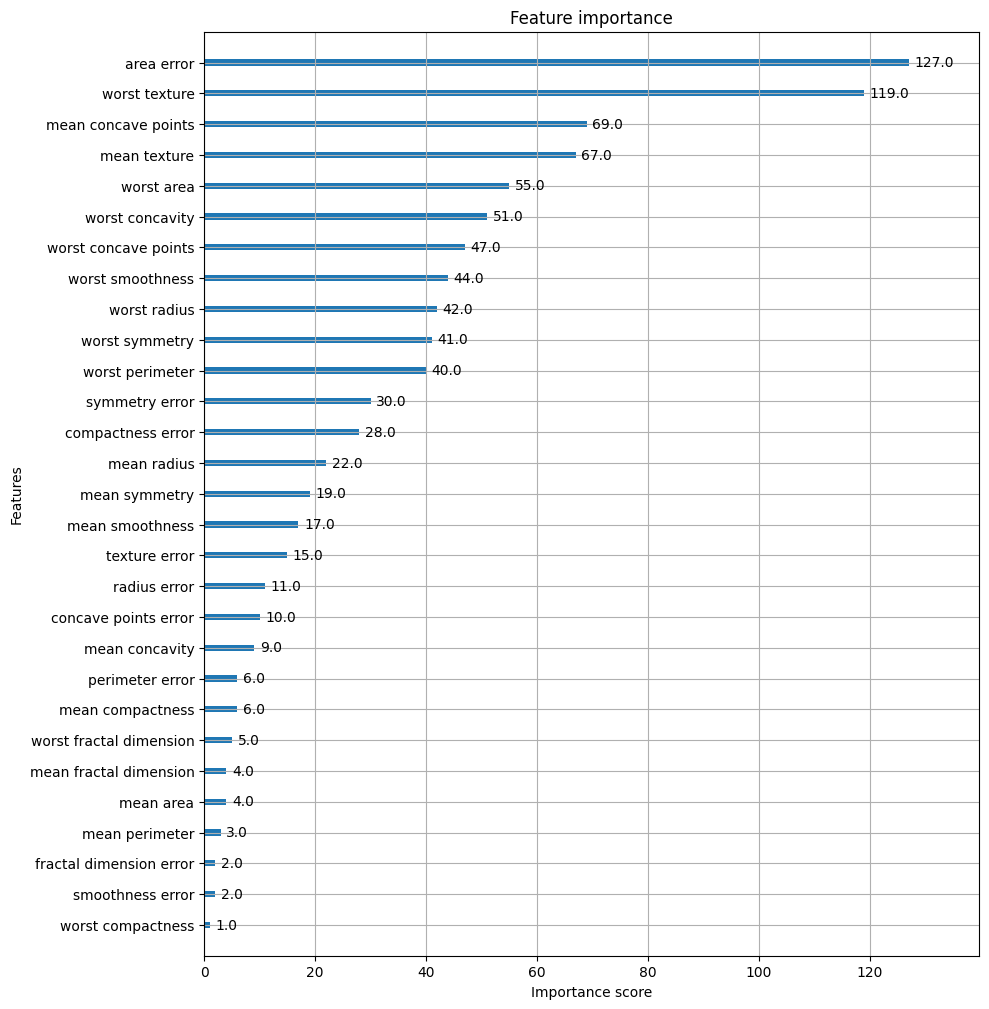

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
plot_importance(xgb_model, ax=ax)

cv() API와 파라미터에 대한 설명

xgboost.cv(params, dtrain, num_boost_ro나nd=10, nfold=3, stratified=False, folds=Nonez metrics=(), obj=None, feval=None, maximize=False, early_stopping_rounds=Non은, fpreproc=None, as_pandas=True, verbose_eval=None, show_stdv=True, seed=Gz callbacks=None, shuffle=True)

- params (dict) : 부스터 파라미터
- dtrain (DMatrix) : 학습 데이터
- num_boost_round (int) : 부스팅 반복 횟수
- nflod (int) : CV 폴드 개수
- stratified (bool) : CV 수행 시 층화 표본 추출 수행 여부
- metric (string or list of strings) : CV 수행 시 모니터링할 성능 평가 지표
- early_stopping_rounds (int) : 조기 중단을 활성화시킴. 반복횟수 지정

##### 사이킷런 래퍼 XGBoost의 개요 및 적용 
사이킷런의 기본 estimator를 그대로 상속해 만들었기 때문에 fit(), predict()만으로 학습과 예측이 가능
- 알고리즘 클래스만 XGBoost 래퍼 클래스로 바꾸면 기존 프로그램도 그대로 사용 가능하다 
- 네이티브 하이퍼 파라미터 몇 개를 변경 
    - eta - learning_rate
    - sub_sample - subsample
    - lambda - reg_lambda
    - alpha - reg_alpha 
    - n_estimators, num_boost_round 하이퍼 파라미터는 서로 동일한 파라미터다

In [15]:
# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier

# Warning 메시지를 없애기 위해 eval_metric 값을 XGBClassifier 생성 인자로 입력.
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3, eval_metric='logloss')
xgb_wrapper.fit(X_train, y_train, verbose=True)
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]

In [16]:
get_clf_eval(y_test, w_preds, w_pred_proba)

오차행렬
[[34  3]
 [ 1 76]]
정확도:0.9649,정밀도:0.9620,재현율:0.9870,F1:0.9744, AUC:0.9530


In [17]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    early_stopping_rounds=50,
    eval_metric='logloss'
)

evals = [(X_tr, y_tr), (X_val, y_val)]

xgb_wrapper.fit(X_tr, y_tr, eval_set=evals, verbose=True)

ws50_preds = xgb_wrapper.predict(X_test)
ws50_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63088
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60461
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58205
[3]	validation_0-logloss:0.52068	validation_1-logloss:0.56165
[4]	validation_0-logloss:0.49173	validation_1-logloss:0.54101
[5]	validation_0-logloss:0.46517	validation_1-logloss:0.52206
[6]	validation_0-logloss:0.44009	validation_1-logloss:0.50271
[7]	validation_0-logloss:0.41646	validation_1-logloss:0.48606
[8]	validation_0-logloss:0.39505	validation_1-logloss:0.46961
[9]	validation_0-logloss:0.37523	validation_1-logloss:0.45485
[10]	validation_0-logloss:0.35682	validation_1-logloss:0.44120
[11]	validation_0-logloss:0.33964	validation_1-logloss:0.43123
[12]	validation_0-logloss:0.32279	validation_1-logloss:0.41962
[13]	validation_0-logloss:0.30783	validation_1-logloss:0.40848
[14]	validation_0-logloss:0.29308	validation_1-logloss:0.39857
[15]	validation_0-logloss:0.27928	validation_1-logloss:0.38945
[1

In [18]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

오차행렬
[[35  2]
 [ 2 75]]
정확도:0.9649,정밀도:0.9740,재현율:0.9740,F1:0.9740, AUC:0.9600


In [19]:
# early_stopping_rounds를 10으로 설정하고 재학습
xgb_wrapper=XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3,
                          early_stopping_rounds=10, eval_metric='logloss')
xgb_wrapper.fit(X_tr,y_tr, eval_set=evals, verbose=True)
ws10_preds=xgb_wrapper.predict(X_test)
ws10_preds_proba=xgb_wrapper.predict_proba(X_test)[:,1]
get_clf_eval(y_test, ws10_preds, ws10_preds_proba)

[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63088
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60461
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58205
[3]	validation_0-logloss:0.52068	validation_1-logloss:0.56165
[4]	validation_0-logloss:0.49173	validation_1-logloss:0.54101
[5]	validation_0-logloss:0.46517	validation_1-logloss:0.52206
[6]	validation_0-logloss:0.44009	validation_1-logloss:0.50271
[7]	validation_0-logloss:0.41646	validation_1-logloss:0.48606
[8]	validation_0-logloss:0.39505	validation_1-logloss:0.46961
[9]	validation_0-logloss:0.37523	validation_1-logloss:0.45485
[10]	validation_0-logloss:0.35682	validation_1-logloss:0.44120
[11]	validation_0-logloss:0.33964	validation_1-logloss:0.43123
[12]	validation_0-logloss:0.32279	validation_1-logloss:0.41962
[13]	validation_0-logloss:0.30783	validation_1-logloss:0.40848
[14]	validation_0-logloss:0.29308	validation_1-logloss:0.39857
[15]	validation_0-logloss:0.27928	validation_1-logloss:0.38945
[1

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

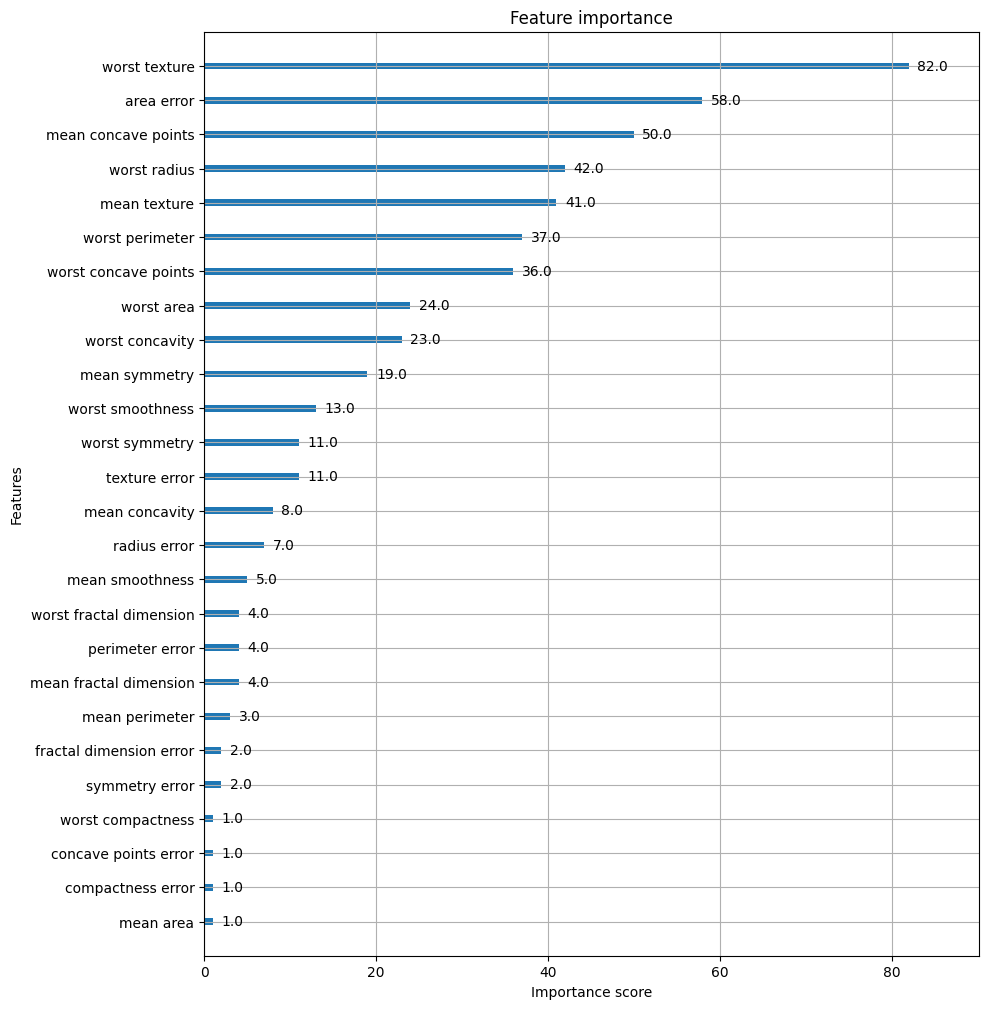

In [20]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
# 사이킷런 래퍼 클래스를 입력해도 무방.
plot_importance(xgb_wrapper, ax=ax)